<a href="https://colab.research.google.com/github/man-of-game/car-prediction-model/blob/main/Group_5_Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step : 1 > Importing the Modules

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import pickle

Step : 2 > Data Collection and Processing

In [ ]:
# loading the Data Set
car_dataset = pd.read_csv('/content/Car Data Set .csv')

In [ ]:
# Checking the Sample of imported Data Set
car_dataset.head()

,Name,Year,Selling_Price,Km_Driven,Fuel_Type,Seller_Type,Transmission,Owners
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [ ]:
# Checking for No. of Rows and Columns
car_dataset.shape

(4340, 8)

In [ ]:
# Checking Information about the Data Set
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           4340 non-null   object
 1   Year           4340 non-null   int64 
 2   Selling_Price  4340 non-null   int64 
 3   Km_Driven      4340 non-null   int64 
 4   Fuel_Type      4340 non-null   object
 5   Seller_Type    4340 non-null   object
 6   Transmission   4340 non-null   object
 7   Owners         4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [ ]:
# Checking for any Missing Values
car_dataset.isnull()

,Name,Year,Selling_Price,Km_Driven,Fuel_Type,Seller_Type,Transmission,Owners
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
4335,False,False,False,False,False,False,False,False
4336,False,False,False,False,False,False,False,False
4337,False,False,False,False,False,False,False,False
4338,False,False,False,False,False,False,False,False


In [ ]:
# Checking Distribution for Fuel Type
print(car_dataset.Fuel_Type.value_counts())
# Checking Distribution for Seller Type
print(car_dataset.Seller_Type.value_counts())
# Checking Distribution for Transmission
print(car_dataset.Transmission.value_counts())
# Checking Distribution for Owners
print(car_dataset.Owners.value_counts())



Fuel_Type
0    2153
1    2123
2      40
3      23
4       1
Name: count, dtype: int64
Seller_Type
0    3244
1     994
2     102
Name: count, dtype: int64
Transmission
0    3892
1     448
Name: count, dtype: int64
Owners
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64


Step : 3 > Converting Text to Numbers for Fuel Type, Seller Type and     Transmission

In [ ]:
# This step is done for making Machine Learning Model understand better (Encoding)
# For Fuel Type
car_dataset.replace({'Fuel_Type':{'Diesel':0,'Petrol':1,'CNG':2,'LPG':3,'Electric':4}},inplace=True)
# For Seller Type
car_dataset.replace({'Seller_Type':{'Individual':0,'Dealer':1,'Trustmark Dealer':2}},inplace=True)
# For Transmission Type
car_dataset.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)
# For Owners
car_dataset.replace({'Owners':{'First Owner':0,'Second Owner':1,'Third Owner':2,'Fourth & Above Owner':3,'Test Drive Car':5}},inplace=True)




/tmp/ipython-input-2108973084.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Owners':{'First Owner':0,'Second Owner':1,'Third Owner':2,'Fourth & Above Owner':3,'Test Drive Car':5}},inplace=True)


In [ ]:
car_dataset.head()

,Name,Year,Selling_Price,Km_Driven,Fuel_Type,Seller_Type,Transmission,Owners
0,Maruti 800 AC,2007,60000,70000,1,0,0,0
1,Maruti Wagon R LXI Minor,2007,135000,50000,1,0,0,0
2,Hyundai Verna 1.6 SX,2012,600000,100000,0,0,0,0
3,Datsun RediGO T Option,2017,250000,46000,1,0,0,0
4,Honda Amaze VX i-DTEC,2014,450000,141000,0,0,0,1


Step : 4 > Splitting the Data and Target

In [ ]:
# Y stores Selling Price Data (Target)
# X stores all Remaining Data (Except Selling_Price)
X = car_dataset.drop(['Selling_Price','Name'],axis=1)
Y = car_dataset['Selling_Price']

In [ ]:
print(X)

      Year  Km_Driven  Fuel_Type  Seller_Type  Transmission  Owners
0     2007      70000          1            0             0       0
1     2007      50000          1            0             0       0
2     2012     100000          0            0             0       0
3     2017      46000          1            0             0       0
4     2014     141000          0            0             0       1
...    ...        ...        ...          ...           ...     ...
4335  2014      80000          0            0             0       1
4336  2014      80000          0            0             0       1
4337  2009      83000          1            0             0       1
4338  2016      90000          0            0             0       0
4339  2016      40000          1            0             0       0

[4340 rows x 6 columns]


In [ ]:
print(Y)

0        60000
1       135000
2       600000
3       250000
4       450000
         ...  
4335    409999
4336    409999
4337    110000
4338    865000
4339    225000
Name: Selling_Price, Length: 4340, dtype: int64


Step : 5 > Splitting Training Data and Test Data

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=2) # 0.2 indicates 20 % data is being tested and remaining for training


Step : 6 > Model Training using Linear Regression

In [ ]:
lin_reg = LinearRegression()

In [ ]:
# Fitting the data of X_train and Y_train into the Model
lin_reg.fit(X_train,Y_train)  # fit() is used for training the model with the data

LinearRegression()

Step : 7 > Training Data Prediction

> Add blockquote



In [ ]:
# Training Data Prediction
training_data_pred = lin_reg.predict(X_train)

In [ ]:
# Checking Error Score between Predicted Data and Actual Data
# We are Using R Square Method for finding Error Score
error_score = metrics.r2_score(Y_train, training_data_pred)
print("Error Score : ", error_score)

Error Score :  0.439190860829503


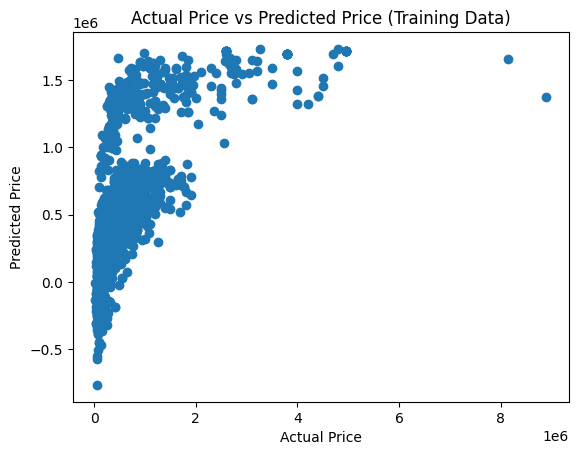

In [ ]:
# Plotting the Graph for this Error
plt.scatter(Y_train, training_data_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price (Training Data)")
plt.show()

Step : 8 > Test Data Prediction

In [ ]:
# Test Data Prediction
test_data_pred = lin_reg.predict(X_test)

In [ ]:
# Checking Error Score between Predicted Data and Actual Data
# We are Using R Square Method for finding Error Score
error_score = metrics.r2_score(Y_test, test_data_pred)
print("Error Score : ", error_score)

Error Score :  0.4998741549737342


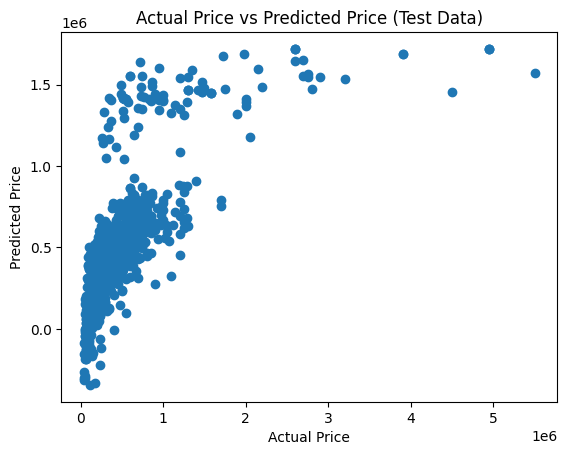

In [ ]:
# Plotting the Graph for this Error
plt.scatter(Y_test, test_data_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price (Test Data)")
plt.show()


In [ ]:
# saving the file as pickle
pickle.dump(lin_reg, open("car_model.pkl", "wb"))
print("Model saved Successfully")

Model saved Successfully
